# Lab 1: Emotion Classification and Error Analysis

[Open this notebook in Google Colab](https://colab.research.google.com/drive/1EMk1gvCePZZHKLl1fpkrFrfNPGG5FWeC)
## Student starter notebook · DSA 495

**Value:** 20% of the final course grade  
**Work format:** Individual

This lab follows the same text from tokenization through two classification
workflows:

1. inspect what the DistilBERT and BART tokenizers receive;
2. evaluate a specialized DistilBERT emotion classifier; and
3. evaluate BART as a zero-shot classifier after selecting label wording on
   a separate development set.

Record your interpretations and answers in the supplied `README.md`.
Keep notebook outputs visible in the submitted copy. You are responsible
for understanding and checking every submitted result.

Use **Runtime → Change runtime type → T4 GPU**, then run cells from top to
bottom. BART evaluates six hypotheses for each message and may take several
minutes even with a GPU.

In [1]:
# Run once at the beginning of a fresh Colab session.
%pip install -q "transformers==4.57.6" "scikit-learn>=1.5,<2" "matplotlib>=3.8,<4" pandas

Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
# Data and reproducibility setup
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

SEED = 495
LABELS = ["sadness", "joy", "love", "anger", "fear", "surprise"]
N_DEV_PER_CLASS = 5
N_SOURCE_TEST = 2000
N_DEVELOPMENT = len(LABELS) * N_DEV_PER_CLASS
N_EVALUATION = N_SOURCE_TEST - N_DEVELOPMENT

COLAB_LAB_DIR = Path(
    "/content/drive/MyDrive/Text analysis for Data Science/Lab 1"
)
LAB_DIR = COLAB_LAB_DIR if COLAB_LAB_DIR.exists() else Path.cwd()
TEST_PATH = LAB_DIR / "emotion.csv"

print("Data file:", TEST_PATH)

Data file: /workspace/scratch/35c9d15f1f4d/lab1_submission/emotion.csv


In [3]:
# Model and evaluation setup
import gc
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from transformers import AutoTokenizer, pipeline, set_seed

ENCODER_ID = "bhadresh-savani/distilbert-base-uncased-finetuned-emotion"
ENCODER_REVISION = "11350faca8e85c4861766cec4c30dec55fd06bb9"
BART_ID = "facebook/bart-large-mnli"
BART_REVISION = "d7645e127eaf1aefc7862fd59a17a5aa8558b8ce"

set_seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 16 if DEVICE == 0 else 8
print("Device:", torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU")

Device: CPU


## 0. Create a clean development/evaluation split

The development set contains five randomly selected messages per emotion.
Use it only to choose between the two zero-shot label formulations. Both
classifiers are evaluated on the same remaining 1,970 messages.

In [4]:
full_test = pd.read_csv(TEST_PATH, dtype={"example_id": "string", "text": "string"})

required_columns = {
    "example_id", "source_split", "source_row", "text", "label_id", "label"
}
assert len(full_test) == N_SOURCE_TEST
assert required_columns.issubset(full_test.columns)
assert full_test["example_id"].is_unique
assert full_test["source_split"].eq("test").all()
assert set(full_test["label"]) == set(LABELS)

rng = random.Random(SEED)
development_indices = []
for label in LABELS:
    candidates = full_test.index[full_test["label"] == label].tolist()
    development_indices.extend(rng.sample(candidates, N_DEV_PER_CLASS))

development_indices = sorted(development_indices)
development = full_test.loc[development_indices].copy().reset_index(drop=True)
evaluation = full_test.drop(index=development_indices).copy().reset_index(drop=True)

assert len(development) == N_DEVELOPMENT
assert len(evaluation) == N_EVALUATION
assert not set(development["example_id"]) & set(evaluation["example_id"])

In [5]:
split_counts = pd.DataFrame({
    "full_test": full_test["label"].value_counts(),
    "development": development["label"].value_counts(),
    "evaluation": evaluation["label"].value_counts(),
}).reindex(LABELS).fillna(0).astype(int)
split_counts["evaluation_percent"] = (
    100 * split_counts["evaluation"] / len(evaluation)
)
display(split_counts)

DISPLAY           full_test  development  evaluation  evaluation_percent
label                                                           
sadness         581            5         576           29.238579
joy             695            5         690           35.025381
love            159            5         154            7.817259
anger           275            5         270           13.705584
fear            224            5         219           11.116751
surprise         66            5          61            3.096447


**Write in `README.md`:** Answer Q1 using the displayed counts. Do not call
this a training/test split; neither model is trained in this notebook.

## 1. Tokenization: What does the model actually receive?

In [6]:
# Load tokenizers only. Model weights are loaded in later sections.
encoder_tokenizer = AutoTokenizer.from_pretrained(
    ENCODER_ID, revision=ENCODER_REVISION
)
bart_tokenizer = AutoTokenizer.from_pretrained(
    BART_ID, revision=BART_REVISION
)
tokenizers = {"DistilBERT": encoder_tokenizer, "BART": bart_tokenizer}

In [7]:
# Replace S1 and S2 with your own diagnostic messages before continuing.
# Together, your examples should include at least two features such as
# capitalization, negation, an emoji, a contraction, or an unfamiliar word.
tokenization_examples = pd.DataFrame([
    ("I1", "instructor", "I can't believe you remembered my birthday!"),
    ("I2", "instructor", "I am not happy about this result."),
    ("I3", "instructor", "I am HAPPY about this result."),
    ("I4", "instructor", "I am happy about this result."),
    ("I5", "instructor", "That surprise made my day 😊!"),
    ("I6", "instructor", "The floccinaucinihilipilification of my work made me angry."),
    ("S1", "student", "I am NOT okay with this result 😟."),
    ("S2", "student", "I feel bittersweet about leaving Raleigh."),
], columns=["example_id", "origin", "text"])

display(tokenization_examples)

DISPLAY   example_id      origin                                                         text
0         I1  instructor                  I can't believe you remembered my birthday!
1         I2  instructor                            I am not happy about this result.
2         I3  instructor                                I am HAPPY about this result.
3         I4  instructor                                I am happy about this result.
4         I5  instructor                                 That surprise made my day 😊!
5         I6  instructor  The floccinaucinihilipilification of my work made me angry.
6         S1     student                            I am NOT okay with this result 😟.
7         S2     student                    I feel bittersweet about leaving Raleigh.


In [8]:
# STUDENT CODE BLOCK 1: build the token table (about 8–10 lines).
# The required output columns and validation checks are supplied.
token_rows = []
for example in tokenization_examples.itertuples():
    for tokenizer_name, tokenizer in tokenizers.items():
        # TODO: tokenize once without and once with special tokens.
        content_ids = tokenizer(example.text, add_special_tokens=False)["input_ids"]
        all_ids = tokenizer(example.text, add_special_tokens=True)["input_ids"]

        token_rows.append({
            "example_id": example.example_id,
            "tokenizer": tokenizer_name,
            # TODO: convert the content IDs to tokenizer vocabulary strings.
            "token_strings": tokenizer.convert_ids_to_tokens(content_ids),
            "token_ids": content_ids,
            # TODO: record both sequence lengths.
            "content_length": len(content_ids),
            "length_with_special_tokens": len(all_ids),
        })

# TODO: convert token_rows to a DataFrame.
token_table = pd.DataFrame(token_rows)

expected_token_columns = {
    "example_id", "tokenizer", "token_strings", "token_ids",
    "content_length", "length_with_special_tokens",
}
assert len(token_table) == len(tokenization_examples) * len(tokenizers)
assert set(token_table.columns) == expected_token_columns
with pd.option_context("display.max_colwidth", None):
    display(token_table)

DISPLAY    example_id   tokenizer                                                                                           token_strings                                                                                                       token_ids  content_length  length_with_special_tokens
0          I1  DistilBERT                                               [i, can, ', t, believe, you, remembered, my, birthday, !]                                                     [1045, 2064, 1005, 1056, 2903, 2017, 4622, 2026, 5798, 999]              10                          12
1          I1        BART                                           [I, Ġcan, 't, Ġbelieve, Ġyou, Ġremembered, Ġmy, Ġbirthday, !]                                                                    [100, 64, 75, 679, 47, 8715, 127, 4115, 328]               9                          11
2          I2  DistilBERT                                                             [i, am, not, happy, about, this, result, .]     

In [9]:
# Use an artificially short limit to make omitted content visible.
long_text = (
    "I described the train ride, the weather, and every stop along the way. " * 4
    + "Despite the ordinary journey, I am terrified about what happens tomorrow."
)

truncation_rows = []
for tokenizer_name, tokenizer in tokenizers.items():
    full = tokenizer(long_text, add_special_tokens=True)
    shortened = tokenizer(
        long_text,
        add_special_tokens=True,
        truncation=True,
        max_length=32,
        return_offsets_mapping=True,
    )
    content_offsets = [
        (start, end)
        for start, end in shortened["offset_mapping"]
        if end > start
    ]
    last_character = max(end for start, end in content_offsets)
    truncation_rows.append({
        "tokenizer": tokenizer_name,
        "full_length": len(full["input_ids"]),
        "truncated_length": len(shortened["input_ids"]),
        "retained_text": tokenizer.decode(
            shortened["input_ids"], skip_special_tokens=True
        ),
        "omitted_suffix": long_text[last_character:],
    })

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(truncation_rows))

DISPLAY     tokenizer  full_length  truncated_length                                                                                                                             retained_text                                                                                                                                                                                                                 omitted_suffix
0  DistilBERT           79                32  i described the train ride, the weather, and every stop along the way. i described the train ride, the weather, and every stop along the   way. I described the train ride, the weather, and every stop along the way. I described the train ride, the weather, and every stop along the way. Despite the ordinary journey, I am terrified about what happens tomorrow.
1        BART           79                32  I described the train ride, the weather, and every stop along the way. I described the train ride, the weather, and every stop along t

**Write in `README.md`:** Answer Q2 and Q3. Token IDs are vocabulary
indices, so their numerical size has no semantic meaning and IDs from the
two tokenizers are not directly comparable.

## 2. Specialized encoder classification

In [10]:
# A constant reference baseline chosen before evaluation.
baseline_label = "joy"
y_true = evaluation["label"].to_numpy()
baseline_predictions = np.repeat(baseline_label, len(evaluation))

def metric_row(method, truth, predictions, seconds=None):
    return {
        "method": method,
        "accuracy": accuracy_score(truth, predictions),
        "macro_f1": f1_score(
            truth,
            predictions,
            labels=LABELS,
            average="macro",
            zero_division=0,
        ),
        "inference_seconds": seconds,
    }

display(pd.DataFrame([
    metric_row("Always predict joy", y_true, baseline_predictions)
]))

DISPLAY                method  accuracy  macro_f1 inference_seconds
0  Always predict joy  0.350254  0.086466              None


In [11]:
encoder = pipeline(
    "text-classification",
    model=ENCODER_ID,
    revision=ENCODER_REVISION,
    tokenizer=encoder_tokenizer,
    device=DEVICE,
)

encoder_label_mapping = {
    int(key): value.lower()
    for key, value in encoder.model.config.id2label.items()
}
print("Checkpoint label mapping:", encoder_label_mapping)
assert set(encoder_label_mapping.values()) == set(LABELS)

Device set to use cpu
Checkpoint label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [12]:
# PROVIDED: run the expensive model inference. Model loading is excluded
# from the timer. Complete the processing block below after this finishes.
start = time.perf_counter()
raw_encoder_predictions = encoder(
    evaluation["text"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=encoder_tokenizer.model_max_length,
    top_k=None,
)
encoder_seconds = time.perf_counter() - start

# STUDENT CODE BLOCK 2: process and evaluate predictions
# (about 13–15 lines). Keep the canonical LABELS column order.
# TODO: turn each list of label/score dictionaries into one DataFrame row.
encoder_scores = pd.DataFrame([
    {item["label"].lower(): item["score"] for item in row}
    for row in raw_encoder_predictions
])[LABELS]
assert encoder_scores.shape == (len(evaluation), len(LABELS))
assert list(encoder_scores.columns) == LABELS

results = evaluation.copy()
# TODO: store the highest-scoring label and its score for every message.
results["encoder_prediction"] = encoder_scores.idxmax(axis=1)
results["encoder_score"] = encoder_scores.max(axis=1)
encoder_predictions = results["encoder_prediction"].to_numpy()

# TODO: calculate accuracy and macro-F1 directly.
encoder_accuracy = accuracy_score(y_true, encoder_predictions)
encoder_macro_f1 = f1_score(y_true, encoder_predictions, labels=LABELS, average="macro", zero_division=0)

# TODO: retain errors and sort them from highest to lowest model score.
encoder_errors = results.loc[results["encoder_prediction"] != results["label"]].sort_values("encoder_score", ascending=False)

encoder_comparison = pd.DataFrame([
    metric_row("Always predict joy", y_true, baseline_predictions),
    {
        "method": "DistilBERT",
        "accuracy": encoder_accuracy,
        "macro_f1": encoder_macro_f1,
        "inference_seconds": encoder_seconds,
    },
])
display(encoder_comparison)

DISPLAY                method  accuracy  macro_f1  inference_seconds
0  Always predict joy  0.350254  0.086466                NaN
1          DistilBERT  0.924365  0.880256          22.824839


DISPLAY               precision    recall  f1-score      support
sadness        0.973451  0.954861  0.964067   576.000000
joy            0.972393  0.918841  0.944858   690.000000
love           0.769231  0.909091  0.833333   154.000000
anger          0.901060  0.944444  0.922242   270.000000
fear           0.878924  0.894977  0.886878   219.000000
surprise       0.707692  0.754098  0.730159    61.000000
accuracy       0.924365  0.924365  0.924365     0.924365
macro avg      0.867125  0.896052  0.880256  1970.000000
weighted avg   0.928457  0.924365  0.925563  1970.000000


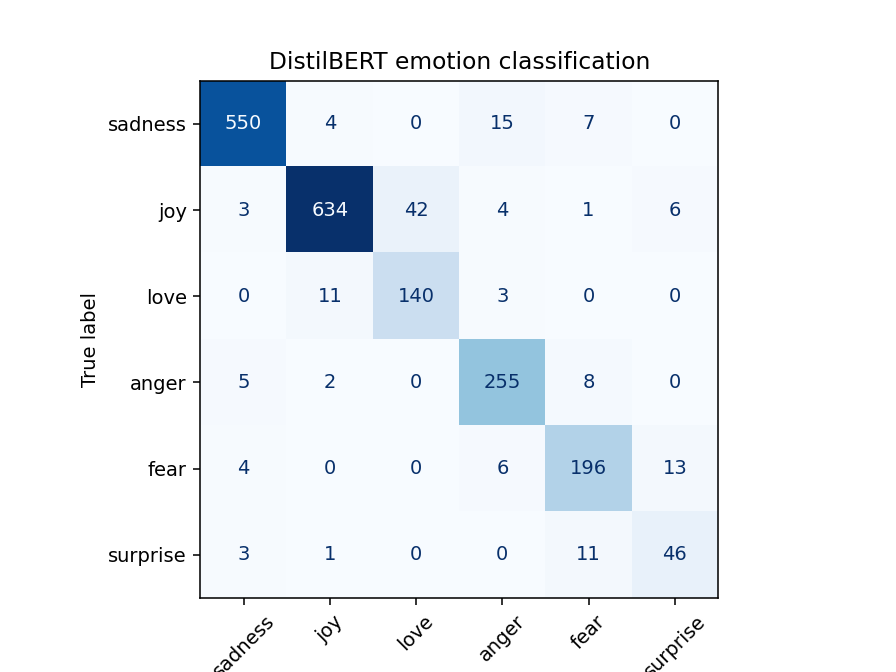

In [13]:
encoder_report = pd.DataFrame(
    classification_report(
        y_true,
        encoder_predictions,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T
display(encoder_report)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    encoder_predictions,
    labels=LABELS,
    display_labels=LABELS,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=45,
)
plt.title("DistilBERT emotion classification")
plt.grid(False)
plt.show()

In [14]:
# PROVIDED: inspect the error table created in Student Code Block 2.
display(
    encoder_errors[
        ["example_id", "text", "label", "encoder_prediction", "encoder_score"]
    ].head(12)
)

DISPLAY               example_id                                                                                                                                                                                                                                    text     label encoder_prediction  encoder_score
1295  emotion_test_01314                                                                                                                                                                                                 ive blogged and i feel strange about it  surprise               fear       0.998750
1358  emotion_test_01377                                                                      i walked to school he felt the bounce in his step the overjoyed feelings of youth and the thrill of excitement of coming to school and meeting his beloved friends      love                joy       0.998552
802   emotion_test_00816                                                                 

**Write in `README.md`:** Complete Q4 and Q5. Examine the message text;
do not infer an error pattern only from the labels or scores.

## 3. Zero-shot classification and label wording

In [15]:
# Release encoder weights before loading the larger BART model.
del encoder, raw_encoder_predictions
gc.collect()
if DEVICE == 0:
    torch.cuda.empty_cache()

zero_shot = pipeline(
    "zero-shot-classification",
    model=BART_ID,
    revision=BART_REVISION,
    tokenizer=bart_tokenizer,
    device=DEVICE,
)

print("BART classification head:", zero_shot.model.config.id2label)

Device set to use cpu
BART classification head: {0: 'contradiction', 1: 'neutral', 2: 'entailment'}


In [16]:
HYPOTHESIS_TEMPLATE = "This text expresses {}."
FORMULATIONS = {
    "A: emotion names": dict(zip(LABELS, LABELS)),
    "B: expanded descriptions": {
        "sadness": "sadness or unhappiness",
        "joy": "happiness or joy",
        "love": "love or affection",
        "anger": "anger or frustration",
        "fear": "fear or anxiety",
        "surprise": "surprise or astonishment",
    },
}

def run_zero_shot(texts, label_mapping):
    description_to_label = {
        description: label
        for label, description in label_mapping.items()
    }
    start = time.perf_counter()
    outputs = zero_shot(
        list(texts),
        candidate_labels=list(label_mapping.values()),
        hypothesis_template=HYPOTHESIS_TEMPLATE,
        multi_label=False,
        batch_size=BATCH_SIZE,
    )
    seconds = time.perf_counter() - start
    scores = pd.DataFrame([
        {
            description_to_label[description]: score
            for description, score in zip(row["labels"], row["scores"])
        }
        for row in outputs
    ]).reindex(columns=LABELS)
    return scores, seconds

In [17]:
development_rows = []
development_predictions = development.copy()

for formulation_name, label_mapping in FORMULATIONS.items():
    scores, seconds = run_zero_shot(development["text"], label_mapping)
    predictions = scores.idxmax(axis=1)
    development_predictions[formulation_name] = predictions
    development_rows.append(
        metric_row(
            formulation_name,
            development["label"],
            predictions,
            seconds,
        )
    )

development_comparison = pd.DataFrame(development_rows).set_index("method")
display(development_comparison)

# STUDENT DECISION LINE: select the formulation with the highest
# development macro-F1. Pandas chooses A if the values tie exactly.
selected_formulation = development_comparison["macro_f1"].idxmax()
selected_labels = FORMULATIONS[selected_formulation]
print("Selected before evaluation:", selected_formulation)

changed = development_predictions.loc[
    development_predictions["A: emotion names"]
    != development_predictions["B: expanded descriptions"]
]
display(
    changed[
        [
            "example_id", "text", "label",
            "A: emotion names", "B: expanded descriptions",
        ]
    ].head(8)
)

DISPLAY                           accuracy  macro_f1  inference_seconds
method                                                         
A: emotion names          0.500000  0.464388          15.621505
B: expanded descriptions  0.566667  0.552279          16.116030
Selected before evaluation: B: expanded descriptions
DISPLAY             example_id                                                                                                                               text    label A: emotion names B: expanded descriptions
4   emotion_test_00332                                                                                 i have better things to do than to feel humiliated  sadness         surprise                  sadness
6   emotion_test_00518                                                                                                       i watched the news at the tv    anger          sadness                 surprise
7   emotion_test_00582                                      

In [18]:
# Final zero-shot evaluation. Do not revise labels after viewing these results.
zero_shot_scores, zero_shot_seconds = run_zero_shot(
    evaluation["text"], selected_labels
)
results["zero_shot_prediction"] = zero_shot_scores.idxmax(axis=1)
results["zero_shot_score"] = zero_shot_scores.max(axis=1)
zero_shot_predictions = results["zero_shot_prediction"].to_numpy()

final_comparison = pd.DataFrame([
    metric_row("Always predict joy", y_true, baseline_predictions),
    metric_row(
        "DistilBERT", y_true, encoder_predictions, encoder_seconds
    ),
    metric_row(
        f"BART zero-shot ({selected_formulation})",
        y_true,
        zero_shot_predictions,
        zero_shot_seconds,
    ),
])
display(final_comparison)

DISPLAY                                       method  accuracy  macro_f1  inference_seconds
0                         Always predict joy  0.350254  0.086466                NaN
1                                 DistilBERT  0.924365  0.880256          22.824839
2  BART zero-shot (B: expanded descriptions)  0.536548  0.479474        1085.135636


DISPLAY               precision    recall  f1-score      support
sadness        0.655290  0.666667  0.660929   576.000000
joy            0.840909  0.428986  0.568138   690.000000
love           0.301887  0.415584  0.349727   154.000000
anger          0.536122  0.522222  0.529081   270.000000
fear           0.523077  0.621005  0.567850   219.000000
surprise       0.121212  0.590164  0.201117    61.000000
accuracy       0.536548  0.536548  0.536548     0.536548
macro avg      0.496416  0.540771  0.479474  1970.000000
weighted avg   0.645109  0.536548  0.561446  1970.000000


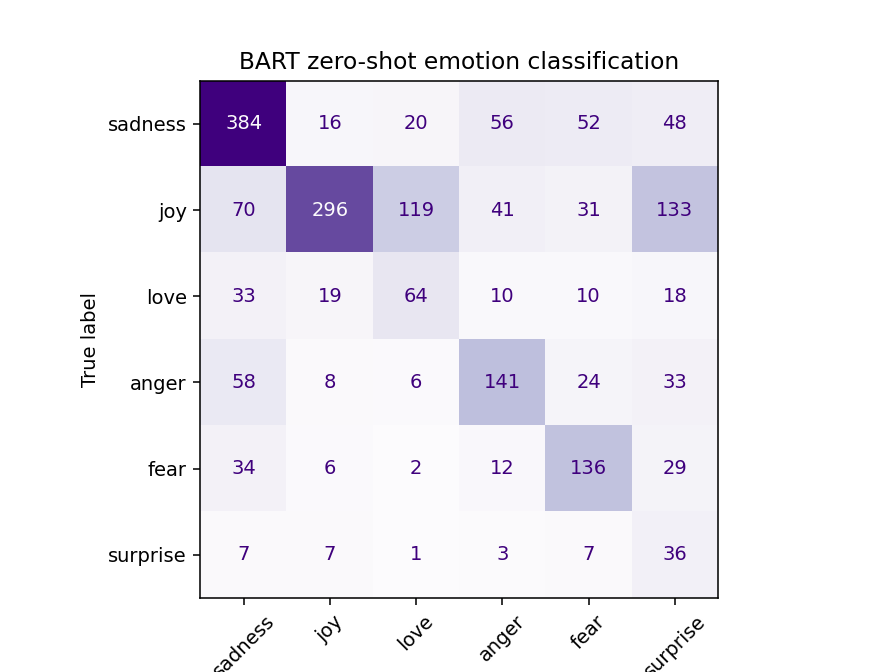

In [19]:
zero_shot_report = pd.DataFrame(
    classification_report(
        y_true,
        zero_shot_predictions,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T
display(zero_shot_report)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    zero_shot_predictions,
    labels=LABELS,
    display_labels=LABELS,
    cmap="Purples",
    colorbar=False,
    xticks_rotation=45,
)
plt.title("BART zero-shot emotion classification")
plt.grid(False)
plt.show()

In [20]:
disagreements = results.loc[
    results["encoder_prediction"] != results["zero_shot_prediction"]
].copy()
disagreements["encoder_correct"] = (
    disagreements["encoder_prediction"] == disagreements["label"]
)
disagreements["zero_shot_correct"] = (
    disagreements["zero_shot_prediction"] == disagreements["label"]
)
disagreements["outcome"] = np.select(
    [disagreements["encoder_correct"], disagreements["zero_shot_correct"]],
    ["encoder only correct", "zero-shot only correct"],
    default="both incorrect",
)

display(disagreements["outcome"].value_counts().rename("count").to_frame())

# Show at least one example from each available outcome, then fill to four.
selected_indices = disagreements.groupby("outcome", sort=True).head(1).index.tolist()
selected_indices += [
    index
    for index in disagreements.index
    if index not in selected_indices
][: max(0, 4 - len(selected_indices))]

four_disagreements = disagreements.loc[selected_indices[:4]]
with pd.option_context("display.max_colwidth", None):
    display(
        four_disagreements[
            [
                "example_id", "text", "label", "encoder_prediction",
                "zero_shot_prediction", "outcome",
            ]
        ]
    )

DISPLAY                         count
outcome                      
encoder only correct      812
zero-shot only correct     48
both incorrect             44
DISPLAY             example_id                                                                                                            text     label encoder_prediction zero_shot_prediction                 outcome
2   emotion_test_00002               i never make her separate from me because i don t ever want her to feel like i m ashamed with her   sadness            sadness                 love    encoder only correct
70  emotion_test_00072  i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird  surprise               fear             surprise  zero-shot only correct
96  emotion_test_00098                                                                 i feel my heart is tortured by what i have done     anger               fear              sadness          both incorrec

In [21]:
# Detailed examples for the README, selected after all evaluations finish.
with pd.option_context("display.max_colwidth", None):
    display(encoder_errors[["example_id", "text", "label", "encoder_prediction", "encoder_score"]].head(20))
    display(changed[["example_id", "text", "label", "A: emotion names", "B: expanded descriptions"]].head(20))
    display(four_disagreements[["example_id", "text", "label", "encoder_prediction", "zero_shot_prediction", "outcome"]])


DISPLAY               example_id                                                                                                                                                                                                                                    text     label encoder_prediction  encoder_score
1295  emotion_test_01314                                                                                                                                                                                                 ive blogged and i feel strange about it  surprise               fear       0.998750
1358  emotion_test_01377                                                                      i walked to school he felt the bounce in his step the overjoyed feelings of youth and the thrill of excitement of coming to school and meeting his beloved friends      love                joy       0.998552
802   emotion_test_00816                                                                 

**Write in `README.md`:** Complete Q6–Q9. Scores from DistilBERT and BART
come from different classification procedures and should not be treated as
directly comparable probabilities of correctness.

## Submission check

Before submitting one `.zip` file through Canvas:

- replace both student tokenization examples;
- run every cell and keep outputs visible;
- complete all nine questions and the AI-use statement in `README.md`;
- make sure `README.md` identifies every included file and explains how to
  rerun the analysis; and
- include the completed notebook and `README.md` in the archive.

Do not include restricted or sensitive data. The course dataset is already
available through the course Google Drive location.